<a href="https://colab.research.google.com/github/Nanase1994/BA820-Unsupervised-and-Unstructured-Machine-Learning-Project-/blob/main/Fei_Han_820_Project_M4_Pet_Cats_in_the_UK_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#820 Project M4 Pet Cats in the UK Q4

**Section B Team 12**

**Fei Han**

##Refined Problem Statement & Focus

**Q4 ( Refined)**: How can unsupervised learning identify spatial and behavioral clusters, and how does feeding type vary across them in relation to hunting and environmental exposure?


**Explain**: In M2 , my original assumption was that feeding type would have a strong impact on cat behavior and significantly influence cluster formation. However,  my analysis indicated that feeding type had only a limited effect on cluster formation, whereas behavioral patterns and geographic location emerged as substantially stronger drivers of segmentation. The dataset is highly imbalanced, with most cats categorized as either mixed food or dry food, and mixed food accounting for the majority. This distribution likely reduces the discriminative power of feeding type as a standalone clustering variable.

Based on these findings, my revised analytical direction is to integrate feeding type with spatial and behavioral features rather than treating it as an independent clustering driver. Location may influence resource availability and environmental exposure, which in turn affects whether cats are well-fed. Additionally, indoor time and prey per month function as meaningful behavioral indicators that capture lifestyle intensity and hunting activity. By combining feeding type with these stronger explanatory dimensions, the clustering structure may better reflect underlying behavioral–environmental interactions rather than isolated attributes.


##Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

cats_gps_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv"
cats_meta_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv"
cats_gps = pd.read_csv(cats_gps_url)
cats_meta = pd.read_csv(cats_meta_url)
print("GPS dataset shape:", cats_gps.shape)
print("Metadata dataset shape:", cats_meta.shape)

cats_gps.head(), cats_meta.head()

GPS dataset shape: (18215, 11)
Metadata dataset shape: (101, 16)


(  tag_id    event_id  visible             timestamp  location_long  \
 0   Ares  3395610551     True  2017-06-24T01:03:57Z      -5.113851   
 1   Ares  3395610552     True  2017-06-24T01:11:20Z      -5.113851   
 2   Ares  3395610553     True  2017-06-24T02:58:16Z      -5.113730   
 3   Ares  3395610554     True  2017-06-24T03:01:26Z      -5.113774   
 4   Ares  3395610555     True  2017-06-24T03:51:58Z      -5.114247   
 
    location_lat  ground_speed  height_above_ellipsoid  \
 0     50.170315           684                  154.67   
 1     50.170315           936                  154.67   
 2     50.169876          2340                   81.35   
 3     50.169827             0                   67.82   
 4     50.170139          4896                  118.03   
 
    algorithm_marked_outlier  manually_marked_outlier               study_name  
 0                     False                    False  Pet Cats United Kingdom  
 1                     False                    False  Pet C

In [2]:
full_cats_data = cats_gps.merge(
    cats_meta,
    on='tag_id',
    how='left'
)
full_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0


In [3]:
cleaned_cats_data = full_cats_data[~full_cats_data['tag_id'].isin(['Ares', 'Wilfred-Tag', 'Lightening Bugg-Tag', 'Jezebel-Tag','Tipsy-Tag','Maggie-Tag','Lily-Tag','Pants-Tag','Neil-Tag','Johnny-Tag','Meg-Tag','Amber-Tag','Charlie3-Tag'])]
cleaned_cats_data = cleaned_cats_data.drop('food_other', axis=1)
cleaned_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,study_site,age_years
103,Athena,3395610893,True,2017-06-24T01:02:13Z,-5.114018,50.170296,360,78.04,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
104,Athena,3395610894,True,2017-06-24T01:05:33Z,-5.113985,50.170277,828,70.43,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
105,Athena,3395610895,True,2017-06-24T02:12:30Z,-5.114270,50.170177,288,65.66,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
106,Athena,3395610896,True,2017-06-24T02:15:29Z,-5.114331,50.170170,0,75.44,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
107,Athena,3395610897,True,2017-06-24T05:30:58Z,-5.114207,50.170303,792,68.41,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0


The Data preprocesssing remained unchanged from the previous work.

##

##EDA update

In [10]:
!pip install contextily

In [11]:
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

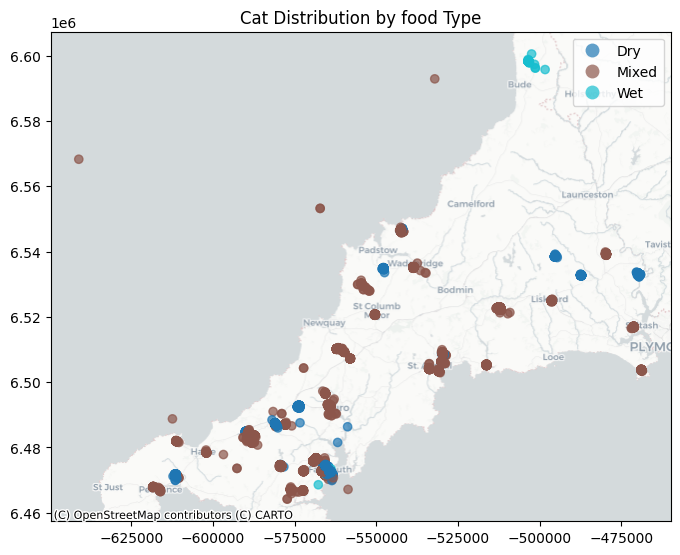

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
if 'food_type' not in cleaned_cats_data.columns:
    cleaned_cats_data['food_type'] = cleaned_cats_data.apply(
        lambda row: 'Mixed' if row['food_dry'] and row['food_wet'] else \
                    'Dry' if row['food_dry'] else \
                    'Wet' if row['food_wet'] else 'Unknown', axis=1
    )

geometry = [Point(xy) for xy in zip(cleaned_cats_data.location_long, cleaned_cats_data.location_lat)]
gdf = gpd.GeoDataFrame(cleaned_cats_data, geometry=geometry,crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(column='food_type',
         categorical= True,
         legend=True,
         alpha=0.7,
         ax=ax)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

plt.title('Cat Distribution by food Type')
plt.show()


analysis:
There is strong spatial overlap between all feeding types; no clear geographic zones are dominated by a single feeding category.

Feeding type does not appear to drive spatial clustering patterns.

Geographic location alone does not explain differences in feeding behavior.


##Experiment and analysis:


###Hierarchical Clustering set up

In [40]:
numeric_cats = cleaned_cats_data.select_dtypes(include=['number'])
drop_cols = ['height_above_ellipsoid','age_years ']
numeric_cats_clean = numeric_cats.drop(columns=drop_cols, errors='ignore')
print(numeric_cats_clean.head())

       event_id  location_long  location_lat  ground_speed  prey_p_month  \
103  3395610893      -5.114018     50.170296           360           3.0   
104  3395610894      -5.113985     50.170277           828           3.0   
105  3395610895      -5.114270     50.170177           288           3.0   
106  3395610896      -5.114331     50.170170             0           3.0   
107  3395610897      -5.114207     50.170303           792           3.0   

     hrs_indoors  n_cats  age_years  
103          7.5       2        3.0  
104          7.5       2        3.0  
105          7.5       2        3.0  
106          7.5       2        3.0  
107          7.5       2        3.0  


In [42]:
cat_level_df = cleaned_cats_data.groupby("tag_id").agg({
    "ground_speed": "mean",
    "prey_p_month": "mean",
    "hrs_indoors": "mean",
    "location_lat": "std",
    "location_long": "std"
})

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cats_scaled = pd.DataFrame(
    scaler.fit_transform(cat_level_df),
    columns=cat_level_df.columns,
    index=cat_level_df.index
)

In [45]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

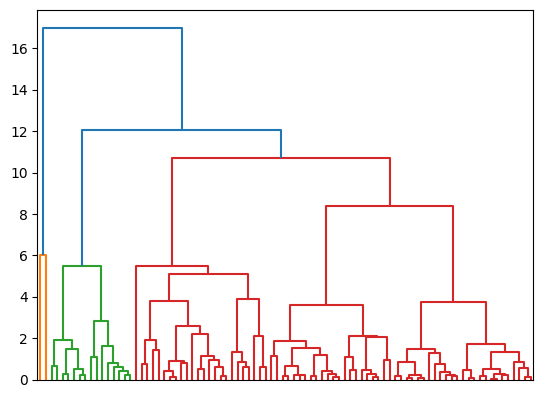

In [46]:
Z = linkage(numeric_cats_scaled, 'ward')

_ = dendrogram(Z, no_labels=True)


In [52]:
n_clusters = 3

numeric_cats_scaled['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)

numeric_cats_scaled

,ground_speed,prey_p_month,hrs_indoors,location_lat,location_long,cluster_labels
tag_id,,,,,,
Abba-Tag,-0.683508,-0.204197,-0.814614,-0.317750,-0.186943,3
Alfie-Tag,-0.155360,-0.204197,-0.814614,-0.203534,-0.066851,3
Athena,0.170993,-0.204197,-0.814614,-0.357202,-0.331389,3
Balu-Tag,-0.037270,-0.204197,-1.783345,-0.326718,-0.286285,3
Barney-Tag,-0.614602,-0.714688,0.154116,-0.317598,-0.322563,3
...,...,...,...,...,...,...
Tom-Tag,-1.211211,1.735672,0.154116,-0.035029,0.058125,2
Tommy-Tag,0.426331,1.735672,0.154116,-0.345540,-0.330634,2
Whiskey-Tag,0.394214,-0.714688,1.122847,-0.316350,-0.301534,3


I refiend my variables for the hirachical cluster, and now there are three very clear clusters, and the food type is still not included in these features.

In [53]:
numeric_cats_scaled['cluster_labels'].value_counts()

,count
cluster_labels,
3,71
2,15
1,2


<Axes: xlabel='hrs_indoors', ylabel='prey_p_month'>

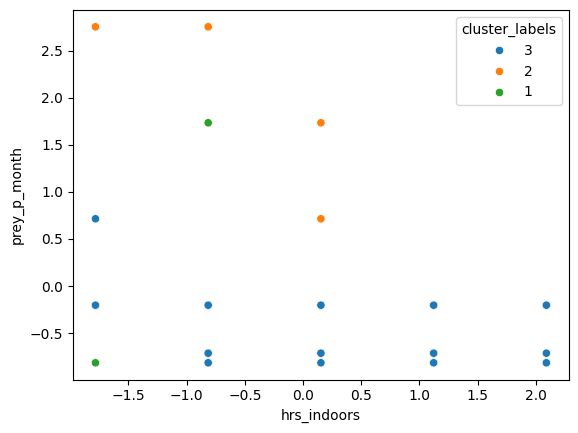

In [57]:
sns.scatterplot(numeric_cats_scaled, x='hrs_indoors', y='prey_p_month', hue='cluster_labels')

Using features alone without PCA shows overlap and unclear cluster.

###K-mean Set Up

In [58]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

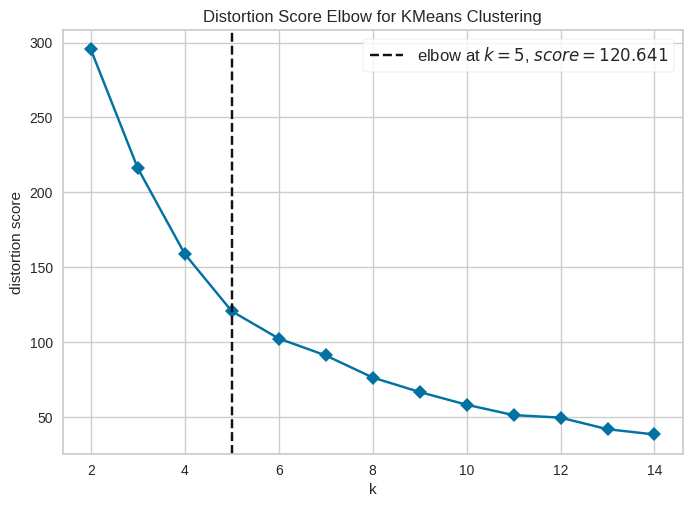

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [62]:
normalized_cat_scaled=(numeric_cats_scaled.drop('cluster_labels',axis=1 ))
clustering = KMeans(random_state=42, n_init='auto')


visualizer = KElbowVisualizer(
    clustering, k=(2, 15), metric='distortion', timings=False, random_state=42
)

visualizer.fit(normalized_cat_scaled)
visualizer.show()

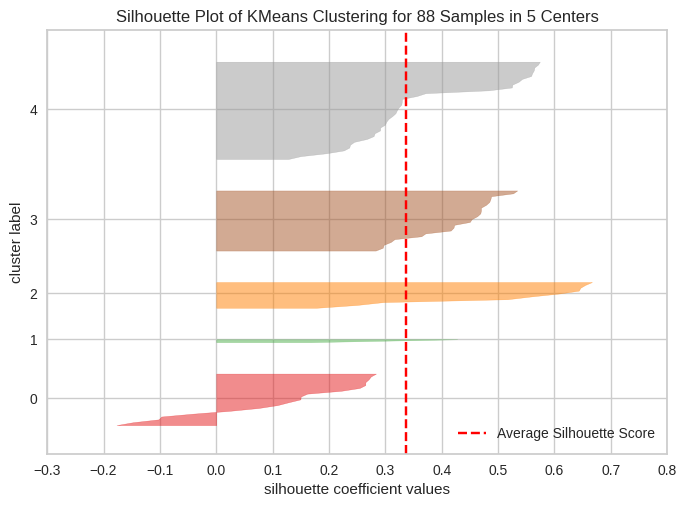

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [71]:
n_clusters_kmeans = 5
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(normalized_cat_scaled)
visualizer.show()

Using k=5 from the elbow graph:


*   The separation is not very strong

*   The clusters size is imbalanced
*   one cluster is very small






###PCA

In [72]:
from sklearn.decomposition import PCA
model = PCA()

model.fit(normalized_cat_scaled)

PCA()

In [74]:
import pandas as pd

transformed_data = model.transform(normalized_cat_scaled)

transformed_data_cat = pd.DataFrame(transformed_data, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
transformed_data_cat

,PC1,PC2,PC3,PC4,PC5
0,-0.212633,0.791434,-0.408138,-0.670921,-0.141760
1,-0.044971,0.482976,0.016854,-0.716209,-0.163698
2,-0.324025,0.381196,0.339999,-0.772281,-0.098102
3,-0.066323,1.042455,0.403639,-1.459598,-0.166268
4,-0.601996,-0.089789,-0.803219,-0.317480,-0.027678
...,...,...,...,...,...
83,0.263950,1.544147,-0.326559,1.388765,0.136303
84,-0.184877,0.816549,1.143020,1.192358,0.132810
85,-0.780280,-1.176460,-0.195576,0.294444,-0.011258
86,-0.547251,0.099593,-0.380812,-0.005974,0.005206


In [75]:
!pip install psynlig -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.2 MB/s eta 0:00:00


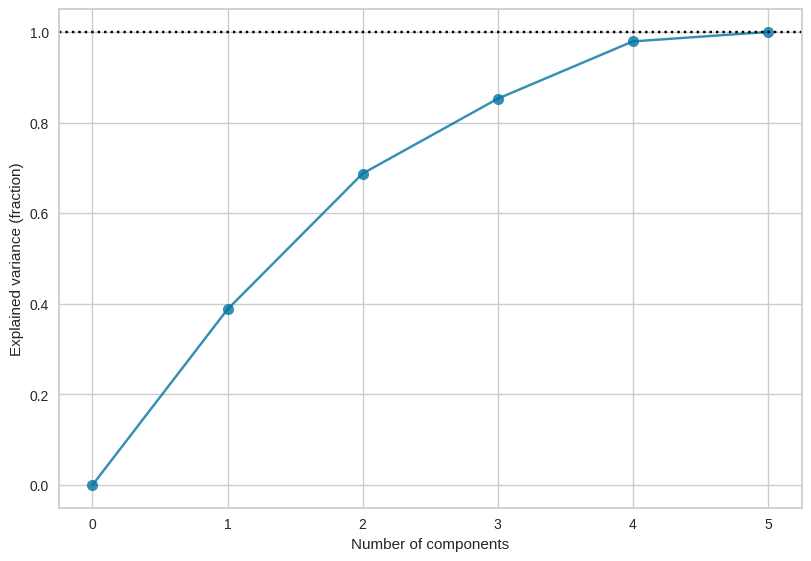

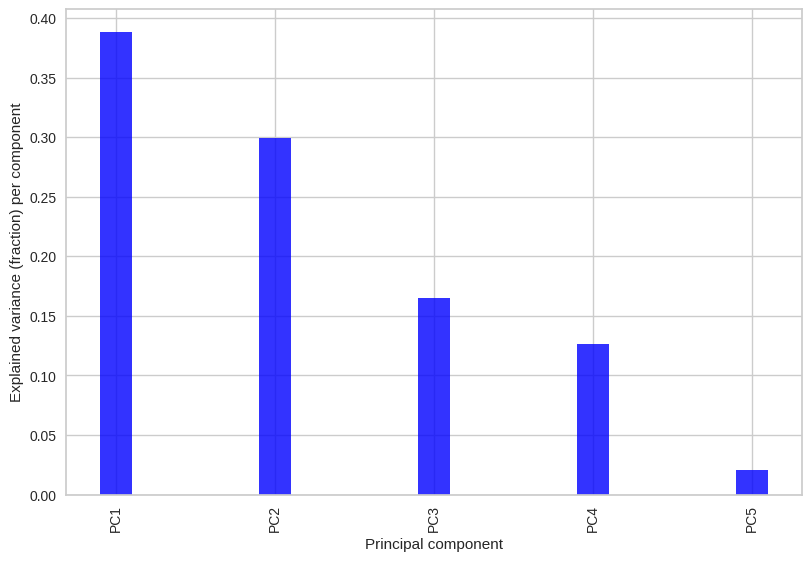

In [77]:
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(model,  marker='o', markersize=8, alpha=0.8)

plt.show()

pca_explained_variance_bar(
    model,
    width=0.2,
    alpha=0.8,
    color='blue',
)

plt.show()

Two main dimensions drive most variation.

PC5 almost have no contribution, and can be reducted

there is no single dominant linear axis.

if keeping at least 80% for variance, we should keep PC1 PC2, and PC3. around 80-90 variance is enouigh

In [79]:
import plotly.express as px


fig = px.scatter_3d(transformed_data_cat, x='PC1', y='PC2', z='PC3')
fig.update_traces(marker_size = 3)
fig.show()

###UMAP

Since there is no clear linear relationship, Switching to UMAP seems to be the better choice.

In [81]:
!pip install umap-learn -q

In [83]:
import umap
reducer = umap.UMAP(n_components=2, )
umap_embeddings = reducer.fit_transform(normalized_cat_scaled)
umap_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2"])

In [86]:
fig = px.scatter(
    umap_df,
    x="UMAP1",
    y="UMAP2",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=4))
fig.show()

In [91]:
reducer = umap.UMAP(n_components=3, )
umap_embeddings = reducer.fit_transform(normalized_cat_scaled)
umap_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2","UMAP3"])

In [93]:
fig = px.scatter_3d(
     umap_df,
     x="UMAP1",
     y="UMAP2",
     z="UMAP3",
     opacity=0.7,
     color_discrete_sequence=px.colors.qualitative.Set2
 )
fig.update_traces(marker=dict(size=4))
fig.show()

The Umap's nonlinear method shows more clear clusters compare to PCA

In [95]:
food_df = cleaned_cats_data.groupby("tag_id")["food_type"].first().reset_index()
cat_level_df = cat_level_df.reset_index()

cat_level_df = cat_level_df.merge(food_df, on="tag_id", how="left")
umap_df = pd.DataFrame(umap_embeddings, columns=["UMAP1","UMAP2","UMAP3"])
umap_df["food_type"] = cat_level_df["food_type"].values

In [97]:

fig = px.scatter_3d(
    umap_df,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="food_type",
    opacity=0.7
)
fig.update_traces(marker=dict(size=4))
fig.show()